# Exploratory Data Analysis onnE-Commerce Data:

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("dataset/data.csv",encoding="cp1252")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Q1. How to find out total no. of records ?

In [4]:
df.shape[0]

541909

In [5]:
print(df.shape[0])

541909


# Q2. How to find out total no. of columns?
 

In [6]:
df.shape[1]

8

# Q3. Display all column names ?
 

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

# Q4. All Column Names Description:-
# InvoiceNo (invoice_num): A number assigned to each transaction
# StockCode (stock_code): Product code
# Description (description): Product name
# Quantity (quantity): Number of products purchased for each transaction
# InvoiceDate (invoice_date): Timestamp for each transaction
# UnitPrice (unit_price): Product price per unit
# CustomerID (cust_id): Unique identifier each customer
# Country (country): Country name


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

# Q5. How to find out all missing values for each columns?

# By understanding the data in a more descriptive manner,
# we notice one thing:
# Quantity has negative values, 
# At this stage, we’ll just remove Quantity with negative values.


In [10]:
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

# Q6. First Show all Quantity has negative values records?


In [12]:
df[df.Quantity<0]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


# Q7. Then find out total shape of Quantity has negative values records? [shape=10624]


In [13]:
df[df.Quantity<0].shape

(10624, 8)

# Q8. How to remove all Quantity records with negative values?


In [15]:
df_new=df[~(df['Quantity']<0)]
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


# Q9. Then find out total records shape ? [df_new.shape is  541909-10624=531285]

# To calculate the total money spent on each purchase, 
# we simply multiply Quantity with Unit Price:
# amount_spent = quantity * unit_price


In [16]:
df_new.shape

(531285, 8)

In [17]:
amount_spent=df_new.Quantity*df_new.UnitPrice

# Q10. After UnitPrice column insert new column Amount_Spent & also formula assigned? In This dataset InvoiceDate column is string form so that:


In [18]:
df_new.insert(6,'Amount_Spent',amount_spent)

In [19]:
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Amount_Spent,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,20.34,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,10.20,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12.60,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,16.60,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,16.60,12680.0,France


# Q11. We add a few columns after InvoiceDate that consist of the Year, Month, Day and Hour for each transaction for analysis work.

In [20]:
df_new.dtypes

InvoiceNo        object
StockCode        object
Description      object
Quantity          int64
InvoiceDate      object
UnitPrice       float64
Amount_Spent    float64
CustomerID      float64
Country          object
dtype: object

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [22]:
df_new['InvoiceDate']=pd.to_datetime(df_new.InvoiceDate)

In [23]:
df_new.dtypes

InvoiceNo               object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
UnitPrice              float64
Amount_Spent           float64
CustomerID             float64
Country                 object
dtype: object

In [24]:
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Amount_Spent,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,20.34,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,10.20,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12.60,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,16.60,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,16.60,12680.0,France


In [25]:
df_new.insert(5,'Year',df_new.InvoiceDate.dt.year)

In [27]:
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Year,UnitPrice,Amount_Spent,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010,3.39,20.34,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011,0.85,10.20,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011,2.10,12.60,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011,4.15,16.60,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011,4.15,16.60,12680.0,France


In [29]:
df_new.insert(6,'Month',df_new.InvoiceDate.dt.month)

In [30]:
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Year,Month,UnitPrice,Amount_Spent,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010,12,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010,12,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010,12,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010,12,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010,12,3.39,20.34,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011,12,0.85,10.20,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011,12,2.10,12.60,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011,12,4.15,16.60,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011,12,4.15,16.60,12680.0,France


In [31]:
df_new.insert(7,'Day',df_new.InvoiceDate.dt.day)

In [32]:
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Year,Month,Day,UnitPrice,Amount_Spent,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010,12,1,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010,12,1,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010,12,1,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010,12,1,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010,12,1,3.39,20.34,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011,12,9,0.85,10.20,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011,12,9,2.10,12.60,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011,12,9,4.15,16.60,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011,12,9,4.15,16.60,12680.0,France


In [33]:
df_new.insert(8,'Hour',df_new.InvoiceDate.dt.hour)

In [34]:
# The final dataframe will look like this:
df_new

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Year,Month,Day,Hour,UnitPrice,Amount_Spent,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010,12,1,8,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010,12,1,8,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010,12,1,8,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010,12,1,8,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010,12,1,8,3.39,20.34,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011,12,9,12,0.85,10.20,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011,12,9,12,2.10,12.60,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011,12,9,12,4.15,16.60,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011,12,9,12,4.15,16.60,12680.0,France


# Q12. InvoiceDate column converts string format into datetime format?


In [13]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [35]:
df_new['InvoiceDate']=pd.to_datetime(df_new['InvoiceDate'])

In [36]:
df_new.dtypes

InvoiceNo               object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Year                     int32
Month                    int32
Day                      int32
Hour                     int32
UnitPrice              float64
Amount_Spent           float64
CustomerID             float64
Country                 object
dtype: object

# Q13. How to find out Top 5 customers with highest money spent records? Show Only 3 columns ['CustomerID','Country','Amount_Spent']


In [39]:
df_n=df_new.Amount_Spent.sort_values(ascending=False).index[:5]
df_n

Index([540421, 61619, 222680, 15017, 299982], dtype='int64')

In [40]:
df_new.loc[df_n,['CustomerID','Country','Amount_Spent']]

,CustomerID,Country,Amount_Spent
540421,16446.0,United Kingdom,168469.60
61619,12346.0,United Kingdom,77183.60
222680,15098.0,United Kingdom,38970.00
15017,NaN,United Kingdom,13541.33
299982,NaN,United Kingdom,11062.06


# Q14. Plotting bar chart : How many orders (per month)?


In [43]:
import matplotlib.pyplot as plt

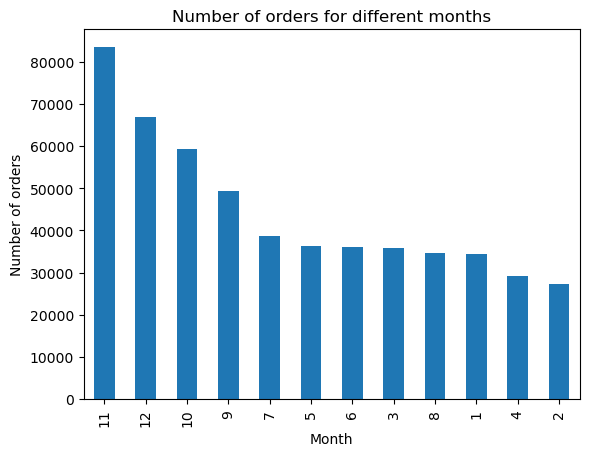

In [44]:
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.title('Number of orders for different months')
df_new.Month.value_counts().plot(kind='bar')
plt.show()

# Q15. Plotting bar chart : How many orders (per day)?


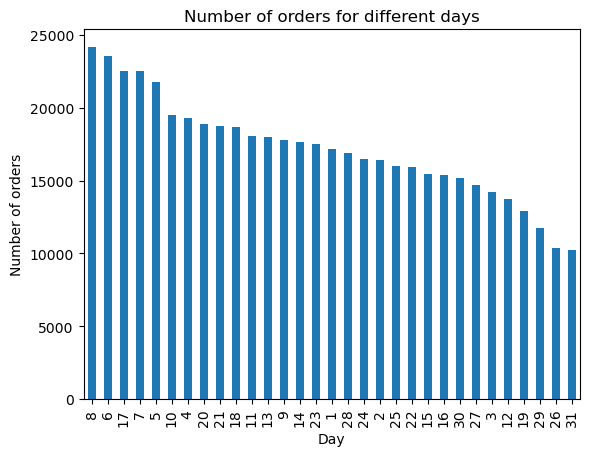

In [45]:
plt.xlabel('Day')
plt.ylabel('Number of orders')
plt.title('Number of orders for different days')
df_new.Day.value_counts().plot(kind='bar')
plt.show()

# Q16. Plotting bar chart : How many orders (per hour)?


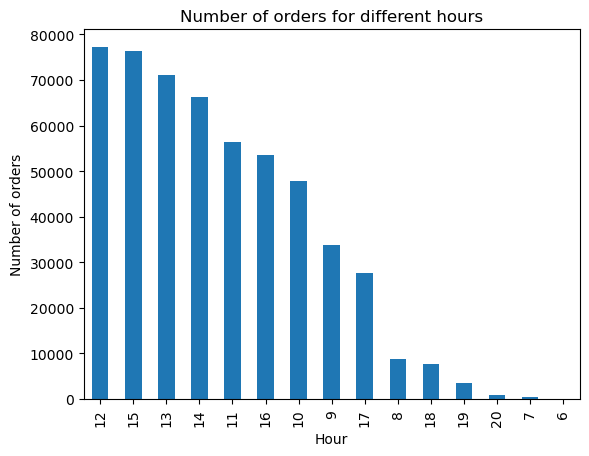

In [46]:
plt.xlabel('Hour')
plt.ylabel('Number of orders')
plt.title('Number of orders for different hours')
df_new.Hour.value_counts().plot(kind='bar')
plt.show()